# Градиентный бустинг (Gradient Boosting)

В программе:
* обучение бустинга и сравнение с лесом
* подбор гиперпараметров бустинга
* зависимость качества от числа деревьев

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.datasets import fetch_california_housing

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import r2_score

In [2]:
RANDOM_STATE = 42

In [3]:
data = fetch_california_housing(as_frame = True)

In [4]:
X = data.data
y = data.target

## Сравнение дерева, леса и градиентного бустинга

In [5]:
%%time

dt = DecisionTreeRegressor() 

cross_val_score(dt, X, y, cv = 3, scoring = 'r2').mean()

CPU times: total: 359 ms
Wall time: 352 ms


np.float64(0.33832973688884205)

In [6]:
%%time

rf = RandomForestRegressor()

cross_val_score(rf, X, y, cv = 3, scoring = 'r2').mean()

CPU times: total: 20.8 s
Wall time: 20.8 s


np.float64(0.6540039733230787)

In [7]:
%%time

gb = GradientBoostingRegressor()

cross_val_score(gb, X, y, cv = 3, scoring = 'r2').mean()

CPU times: total: 6.81 s
Wall time: 6.81 s


np.float64(0.6800120069771115)

## 2. Подбор гиперпараметров бустинга

Напомним, как мы действуем при подборе гиперпараметров:
* разбиваем данные на *train* и *test*
* на *train* по кросс-валидации при помощи `GridSearchCV` ищем наилучшие гиперпараметры модели
* оцениваем качество модели с наилучшими гиперпараметрами на *test*

In [8]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)

### Гиперпараметры бустинга (gradient boosting)

* `n_estimators=100` - число деревьев в лесе 
* `learning_rate=0.1` - градиентный шаг (= степень доверия каждой модели в композиции)
* гиперпараметры деревьев (обсуждали раньше):
  * `criterion='squared_error'`
  * `max_depth=None`
  * `min_samples_split=2`
  * ...
  * `random_state=None`

In [17]:
%%time

params = {'n_estimators' : np.arange(10, 200, 20), 
          'max_depth' : np.arange(2, 20, 3)}

gs = GridSearchCV(GradientBoostingRegressor(), params, cv = 3, scoring = 'r2', verbose = 3)

gs.fit(Xtrain, ytrain)

Fitting 3 folds for each of 60 candidates, totalling 180 fits
[CV 1/3] END ......max_depth=2, n_estimators=10;, score=0.438 total time=   0.0s
[CV 2/3] END ......max_depth=2, n_estimators=10;, score=0.440 total time=   0.0s
[CV 3/3] END ......max_depth=2, n_estimators=10;, score=0.436 total time=   0.0s
[CV 1/3] END ......max_depth=2, n_estimators=30;, score=0.631 total time=   0.2s
[CV 2/3] END ......max_depth=2, n_estimators=30;, score=0.633 total time=   0.2s
[CV 3/3] END ......max_depth=2, n_estimators=30;, score=0.619 total time=   0.2s
[CV 1/3] END ......max_depth=2, n_estimators=50;, score=0.699 total time=   0.4s
[CV 2/3] END ......max_depth=2, n_estimators=50;, score=0.706 total time=   0.5s
[CV 3/3] END ......max_depth=2, n_estimators=50;, score=0.685 total time=   0.5s
[CV 1/3] END ......max_depth=2, n_estimators=70;, score=0.731 total time=   0.7s
[CV 2/3] END ......max_depth=2, n_estimators=70;, score=0.739 total time=   0.7s
[CV 3/3] END ......max_depth=2, n_estimators=70

KeyboardInterrupt: 

In [20]:
%%time

gb = GradientBoostingRegressor(max_depth = 8, n_estimators = 170)

cross_val_score(gb, X, y, cv = 3, scoring = 'r2').mean()

CPU times: total: 29.2 s
Wall time: 29.2 s


np.float64(0.6665109401703917)

In [19]:
%%time

gb = GradientBoostingRegressor(max_depth = 8, n_estimators = 190)

cross_val_score(gb, X, y, cv = 3, scoring = 'r2').mean()

CPU times: total: 32.7 s
Wall time: 32.7 s


np.float64(0.663067437045341)

In [15]:
gb_best_score = gs.best_score_
gb_best_est = gs.best_estimator_
gb_best_params = gs.best_params_

In [16]:
gb_best_score, gb_best_est, gb_best_params

(np.float64(0.8244465772301416),
 GradientBoostingRegressor(max_depth=np.int64(8), n_estimators=np.int64(190)),
 {'max_depth': np.int64(8), 'n_estimators': np.int64(190)})

In [21]:
params = {'max_features': [None, 'sqrt', 'log2']}

gs = GridSearchCV(GradientBoostingRegressor(n_estimators = 170, max_depth = 8), params, cv=3, scoring='r2', verbose=2)

gs.fit(Xtrain, ytrain)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV] END ..................................max_features=None; total time=   6.7s
[CV] END ..................................max_features=None; total time=   6.8s
[CV] END ..................................max_features=None; total time=   6.8s
[CV] END ..................................max_features=sqrt; total time=   1.8s
[CV] END ..................................max_features=sqrt; total time=   1.8s
[CV] END ..................................max_features=sqrt; total time=   1.8s
[CV] END ..................................max_features=log2; total time=   2.6s
[CV] END ..................................max_features=log2; total time=   2.6s
[CV] END ..................................max_features=log2; total time=   2.6s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...stimators=170)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_features': [None, 'sqrt', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candi

In [22]:
gb1_best_score = gs.best_score_
gb1_best_est = gs.best_estimator_
gb1_best_params = gs.best_params_

In [23]:
gb1_best_score, gb1_best_est, gb1_best_params

(np.float64(0.8296670130161036),
 GradientBoostingRegressor(max_depth=8, max_features='log2', n_estimators=170),
 {'max_features': 'log2'})

Теперь проверим полученную модель на тестовых данных

In [25]:
model = GradientBoostingRegressor(n_estimators = 170, learning_rate = 0.1, max_depth = 8, max_features = 'log2')

model.fit(Xtrain, ytrain)

pred = model.predict(Xtest)

r2_score(ytest, pred)

0.8427223164110316

На качество бустинга влияет `learning_rate`.

Стратегия такая: после подбора гиперпараметров мы уменьшаем `learning_rate` до 0.01-0.03  
(то есть если значение по умолчанию 0.1, то уменьшаем в 10 раз), и во столько же раз увеличиваем число деревьев.

In [27]:
model = GradientBoostingRegressor(n_estimators = 1700, learning_rate = 0.01, max_depth = 8, max_features = 'log2')

model.fit(Xtrain, ytrain)

pred = model.predict(Xtest)

r2_score(ytest, pred)

0.8512261670878198

При помощи случайного леса в предыдущем уроке нам удалось добиться качества $r2=0.815$.

Мы видим, что в этой задаче бустинг значительно превзошел по качеству алгоритм случайного леса!

## 3. Поведение модели при увеличении числа деревьев

Text(0, 0.5, 'r2')

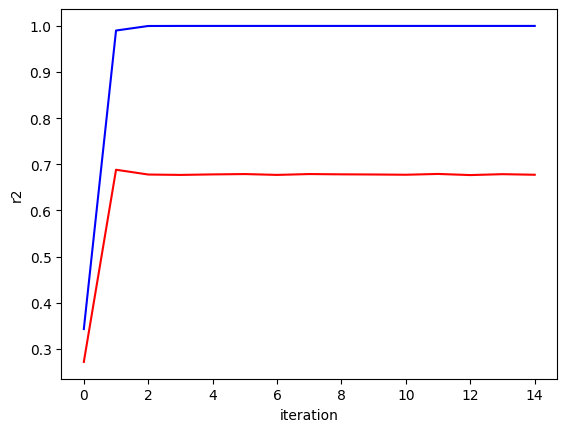

In [28]:
r2_train = []
r2_test = []

for n in range(2, 300, 20):
    model = GradientBoostingRegressor(n_estimators = n, max_depth = 20)
    model.fit(Xtrain, ytrain)

    pred_train = model.predict(Xtrain)
    pred_test = model.predict(Xtest)

    r2_train.append(r2_score(ytrain, pred_train))
    r2_test.append(r2_score(ytest, pred_test))

plt.plot(r2_train, color='blue')
plt.plot(r2_test, color='red')
plt.xlabel('iteration')
plt.ylabel('r2')

Эти графики подтверждают теорию: при увеличении числа деревьев в бустинге качество на тренировочных данных сначала растет, а потом начинает уменьшаться (так как начинается переобучение).

Поэтому на практике необходимо подобрать такое число деревьев, при котором качество на тестовых данных максимальное (и больше деревьев не брать!). В этом одно из важных отличий бустинга от леса.